<a href="https://colab.research.google.com/github/OmaRecalde/machinelearning2026/blob/main/Test_parcial1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad Práctico Experimental: Regresión Lineal Múltiple
**Asignatura:** Machine Learning 2 | **Docente:** Msc. Elvis Pachacama (c)
**Estudiante:** Omar Recalde | **Carrera:** Desarrollo de Software

**Link Github** : [link text](https://github.com/OmaRecalde/machinelearning2026/blob/15c475efacbeed2a09d9398c34c4ac1d09237432/Test_parcial1.ipynb)

## Objetivo
Construir un modelo de regresión lineal múltiple para estimar los gastos médicos (`charges`) a partir de las características de los asegurados.

## Pipeline del proyecto
Carga → EDA → Outliers → Preparación de variables → Escalado → Selección de atributos → Validación → Entrenamiento → Evaluación → Predicción

In [1]:
!pip -q install kagglehub

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

## 1. Carga y comprensión de los datos
Se descarga el dataset directamente desde Kaggle con `kagglehub`, de forma automatizada y sin subir archivos manualmente.

In [2]:
ruta = kagglehub.dataset_download("mirichoi0218/insurance")
print("Ruta del dataset:", ruta)
print("Archivos:", os.listdir(ruta))

df = pd.read_csv(os.path.join(ruta, "insurance.csv"))
df.head()

Using Colab cache for faster access to the 'insurance' dataset.
Ruta del dataset: /kaggle/input/insurance
Archivos: ['insurance.csv']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nInformación general:")
df.info()

Dimensiones: (1338, 7)

Tipos de datos:
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
display(df.describe())
display(df.describe(include="object"))

for col in ["sex", "smoker", "region", "children"]:
    print(f"\n{col}:\n{df[col].value_counts()}")

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364



sex:
sex
male      676
female    662
Name: count, dtype: int64

smoker:
smoker
no     1064
yes     274
Name: count, dtype: int64

region:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

children:
children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


### Diccionario de variables
| Variable | Tipo | Descripción |
|---|---|---|
| age | Numérica | Edad del asegurado |
| sex | Categórica | Sexo (male/female) |
| bmi | Numérica | Índice de masa corporal |
| children | Numérica (discreta) | Número de dependientes |
| smoker | Categórica | Condición de fumador (yes/no) |
| region | Categórica | Región (northeast, northwest, southeast, southwest) |
| charges | Numérica | **Variable objetivo**: gastos médicos |

**Observación:** el dataset tiene 1338 registros y 7 columnas. Se espera una relación fuerte entre `smoker` y `charges`.

## 2. EDA y calidad de los datos
Reviso valores nulos y duplicados, y luego analizo cómo se distribuyen las variables y cómo se relacionan con `charges`.

In [6]:
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\nFilas duplicadas:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Dimensiones después de eliminar duplicados:", df.shape)

Valores nulos por columna:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Filas duplicadas: 1
Dimensiones después de eliminar duplicados: (1337, 7)


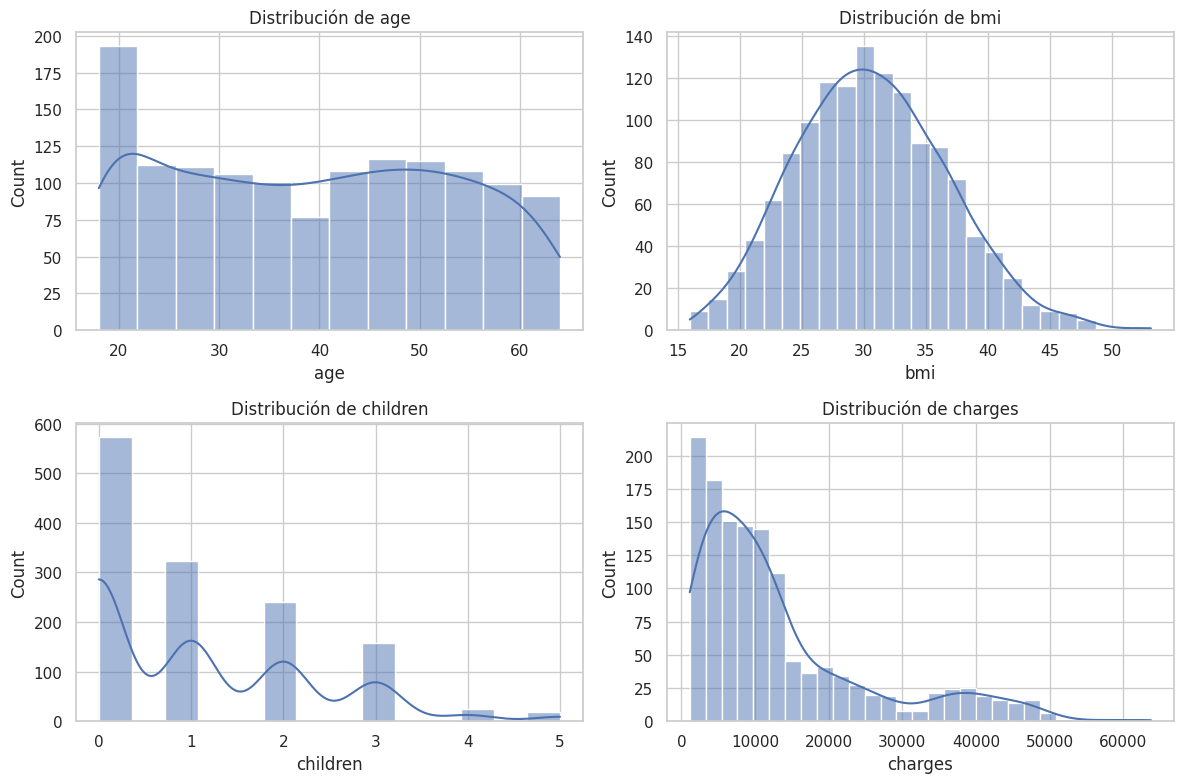

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), ["age", "bmi", "children", "charges"]):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f"Distribución de {col}")
plt.tight_layout()
plt.show()

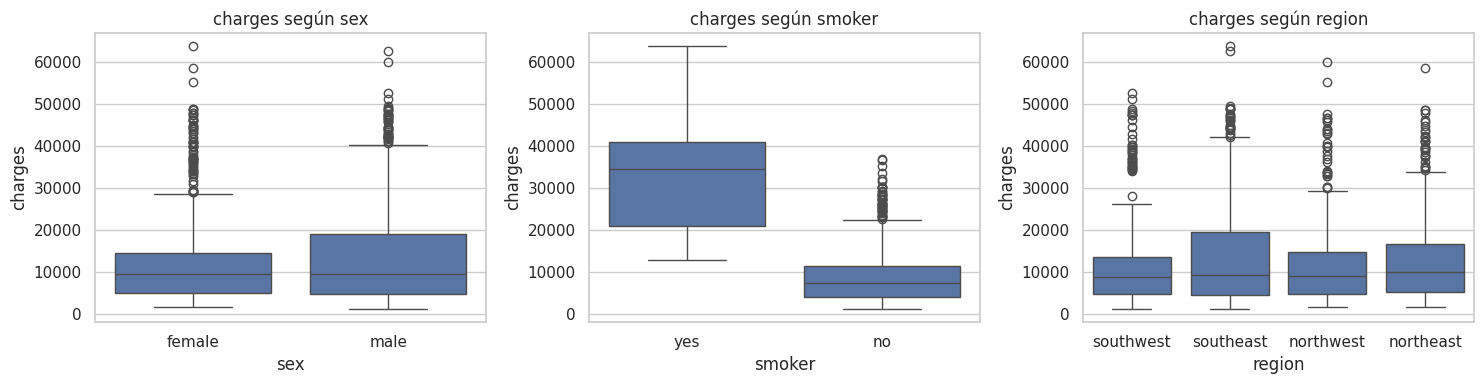

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["sex", "smoker", "region"]):
    sns.boxplot(data=df, x=col, y="charges", ax=ax)
    ax.set_title(f"charges según {col}")
plt.tight_layout()
plt.show()

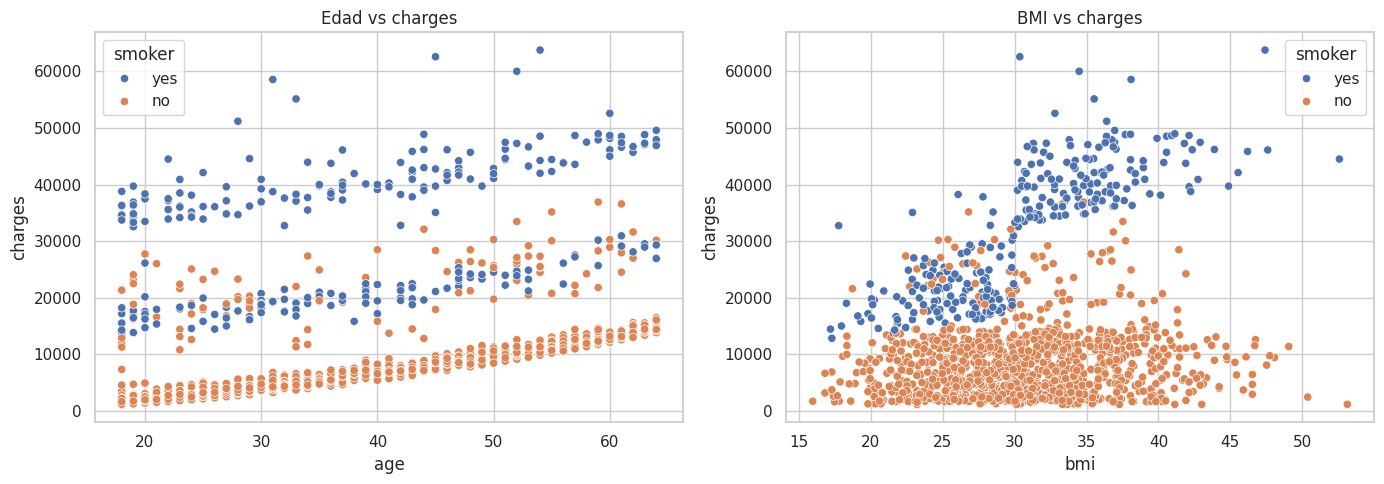

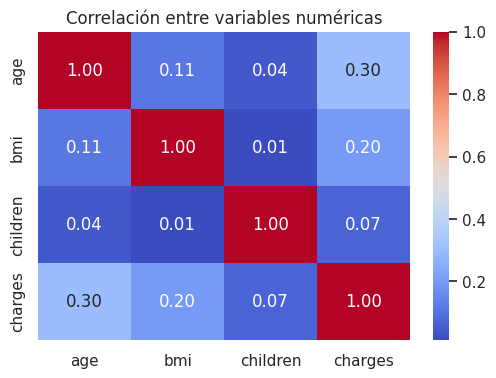

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(data=df, x="age", y="charges", hue="smoker", ax=axes[0])
axes[0].set_title("Edad vs charges")
sns.scatterplot(data=df, x="bmi", y="charges", hue="smoker", ax=axes[1])
axes[1].set_title("BMI vs charges")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.heatmap(df[["age", "bmi", "children", "charges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlación entre variables numéricas")
plt.show()

### Hallazgos del EDA
- No hay valores nulos. Se eliminó una fila duplicada.
- `charges` tiene una distribución sesgada a la derecha: la mayoría de los gastos son bajos y unos pocos son muy altos.
- Los fumadores tienen gastos mucho más altos que los no fumadores.
- `age` muestra una relación positiva con `charges`; `sex` y `region` casi no cambian la distribución.
- En el scatter de BMI se ve que los fumadores con BMI alto concentran los gastos más altos.

## 3. Detección de outliers
Uso el método del rango intercuartílico (IQR): se marca como atípico todo valor fuera de [Q1 − 1.5·IQR, Q3 + 1.5·IQR].

,variable,lim_inf,lim_sup,outliers
0,age,-9.00,87.00,0
1,bmi,13.67,47.32,9
2,charges,-13120.72,34524.78,139


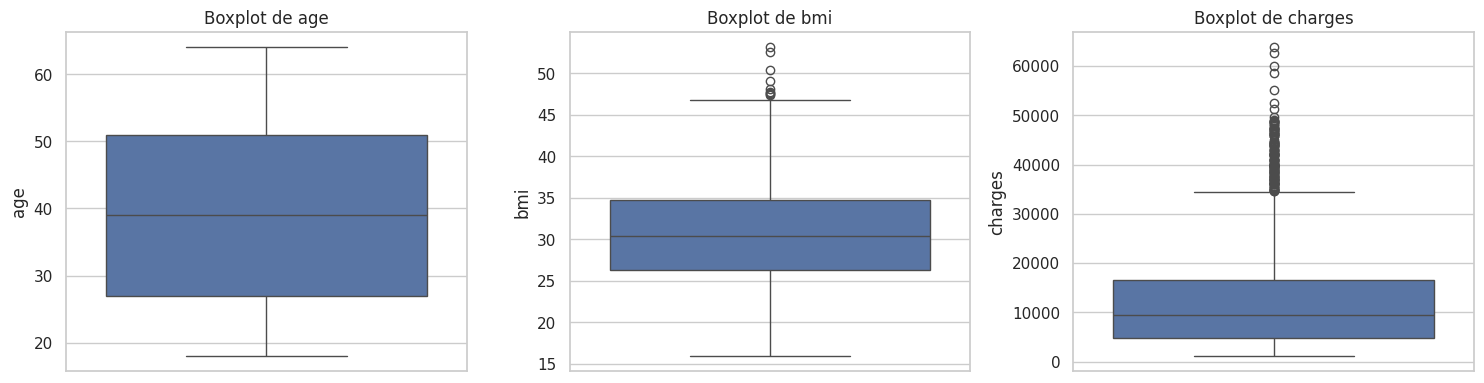

In [10]:
def limites_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

resumen = []
for col in ["age", "bmi", "charges"]:
    li, ls = limites_iqr(df[col])
    n = ((df[col] < li) | (df[col] > ls)).sum()
    resumen.append({"variable": col, "lim_inf": round(li, 2), "lim_sup": round(ls, 2), "outliers": n})
display(pd.DataFrame(resumen))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["age", "bmi", "charges"]):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

In [11]:
_, ls_charges = limites_iqr(df["charges"])
out_charges = df[df["charges"] > ls_charges]
print("Outliers de charges según smoker:")
print(out_charges["smoker"].value_counts())

Outliers de charges según smoker:
smoker
yes    136
no       3
Name: count, dtype: int64


In [12]:
li_bmi, ls_bmi = limites_iqr(df["bmi"])
df["bmi"] = df["bmi"].clip(lower=li_bmi, upper=ls_bmi)
print("BMI después del tratamiento -> min:", df["bmi"].min(), "| max:", df["bmi"].max())

BMI después del tratamiento -> min: 15.96 | max: 47.31500000000001


### Decisión sobre los outliers
- **`charges`:** los valores altos no son errores. Corresponden en gran parte a fumadores, así que los conservo: son información real que el modelo necesita aprender.
- **`bmi`:** los pocos valores extremos se limitan a los bordes del IQR (winsorización) para que no distorsionen los coeficientes.
- **`age`:** no presenta outliers.

## 4. Preparación de variables
El modelo solo acepta números, así que convierto las variables categóricas:
- `sex` y `smoker` son binarias: se codifican como 0/1.
- `region` tiene 4 categorías: one-hot encoding con `drop_first=True` para evitar multicolinealidad (la región de referencia es `northeast`).

In [13]:
df_prep = df.copy()
df_prep["sex"] = df_prep["sex"].map({"female": 0, "male": 1})
df_prep["smoker"] = df_prep["smoker"].map({"no": 0, "yes": 1})
df_prep = pd.get_dummies(df_prep, columns=["region"], drop_first=True, dtype=int)

display(df_prep.head())
print(df_prep.dtypes)

,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,0,0,1
1,18,1,33.770,1,0,1725.55230,0,1,0
2,28,1,33.000,3,0,4449.46200,0,1,0
3,33,1,22.705,0,0,21984.47061,1,0,0
4,32,1,28.880,0,0,3866.85520,1,0,0


age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object


## 5. Normalización o estandarización
`age`, `bmi` y `children` están en escalas muy distintas. Comparo `StandardScaler` (media 0, desviación 1) y `MinMaxScaler` (rango 0 a 1). Elijo **StandardScaler**, que es el habitual en regresión lineal.

Para evitar fuga de datos (data leakage), el escalador del modelo final se ajusta **solo con el conjunto de entrenamiento**, dentro de un Pipeline (Etapa 7).

In [14]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

cols_num = ["age", "bmi", "children"]
std = pd.DataFrame(StandardScaler().fit_transform(df_prep[cols_num]), columns=cols_num)
mm = pd.DataFrame(MinMaxScaler().fit_transform(df_prep[cols_num]), columns=cols_num)

comparacion = pd.concat([
    df_prep[cols_num].describe().T[["mean", "std", "min", "max"]].add_suffix("_original"),
    std.describe().T[["mean", "std"]].add_suffix("_standard"),
    mm.describe().T[["min", "max"]].add_suffix("_minmax"),
], axis=1)
display(comparacion.round(3))

,mean_original,std_original,min_original,max_original,mean_standard,std_standard,min_minmax,max_minmax
age,39.222,14.044,18.00,64.000,-0.0,1.0,0.0,1.0
bmi,30.650,6.060,15.96,47.315,-0.0,1.0,0.0,1.0
children,1.096,1.206,0.00,5.000,0.0,1.0,0.0,1.0


## 6. Selección de atributos
Combino tres criterios: correlación con `charges`, prueba F univariada y los p-valores de una regresión OLS (statsmodels). Me quedo con las variables significativas (p < 0.05).

In [15]:
from sklearn.feature_selection import f_regression

X = df_prep.drop(columns="charges")
y = df_prep["charges"]

corr = df_prep.corr()["charges"].drop("charges").sort_values(key=abs, ascending=False)
print("Correlación con charges:")
display(corr.round(3))

f, p = f_regression(X, y)
display(pd.DataFrame({"variable": X.columns, "F": f.round(1), "p_valor": p.round(4)}).sort_values("F", ascending=False))

Correlación con charges:


,charges
smoker,0.787
age,0.298
bmi,0.199
region_southeast,0.074
children,0.067
sex,0.058
region_southwest,-0.044
region_northwest,-0.039


,variable,F,p_valor
4,smoker,2175.7,0.0000
0,age,130.4,0.0000
2,bmi,55.1,0.0000
6,region_southeast,7.3,0.0071
3,children,6.1,0.0137
1,sex,4.5,0.0338
7,region_southwest,2.5,0.1107
5,region_northwest,2.0,0.1573


In [16]:
import statsmodels.api as sm

ols = sm.OLS(y, sm.add_constant(X)).fit()
print(ols.summary())

pvals = ols.pvalues.drop("const")
columnas_finales = pvals[pvals < 0.05].index.tolist()
print("\nAtributos seleccionados:", columnas_finales)
print("Descartados:", [c for c in X.columns if c not in columnas_finales])

                            OLS Regression Results                            
Dep. Variable:                charges   R-squared:                       0.751
Model:                            OLS   Adj. R-squared:                  0.749
Method:                 Least Squares   F-statistic:                     500.2
Date:                Thu, 01 Oct 2026   Prob (F-statistic):               0.00
Time:                        01:10:19   Log-Likelihood:                -13538.
No. Observations:                1337   AIC:                         2.709e+04
Df Residuals:                    1328   BIC:                         2.714e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.201e+04    991.475  

### Resultado de la selección
Se conservan las variables con p-valor menor a 0.05. Las descartadas aportan poca información adicional una vez que se consideran las demás. Para esta práctica la selección se hizo con todos los datos; en un proyecto real conviene hacerla solo con el conjunto de entrenamiento.

## 7. Validación de datos
Separo 80% para entrenar y 20% para probar. Armo un Pipeline que escala las variables numéricas y aplica la regresión, y lo valido con validación cruzada de 5 folds sobre el conjunto de entrenamiento.

In [17]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

X = df_prep[columnas_finales]
y = df_prep["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, "| Test:", X_test.shape)

num_cols = [c for c in ["age", "bmi", "children"] if c in columnas_finales]
prep = ColumnTransformer([("num", StandardScaler(), num_cols)], remainder="passthrough")
modelo = Pipeline([("prep", prep), ("lr", LinearRegression())])

cv = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="r2")
print("R² por fold:", scores.round(3))
print(f"R² promedio CV: {scores.mean():.3f} (± {scores.std():.3f})")

Train: (1069, 6) | Test: (268, 6)
R² por fold: [0.728 0.717 0.773 0.69  0.71 ]
R² promedio CV: 0.724 (± 0.028)


## 8. Entrenamiento mediante regresión lineal
Entreno el Pipeline completo con el conjunto de entrenamiento y reviso los coeficientes. Las variables numéricas están estandarizadas, así que sus coeficientes indican el efecto de aumentar una desviación estándar.

In [18]:
modelo.fit(X_train, y_train)

nombres = num_cols + [c for c in X.columns if c not in num_cols]
coefs = pd.DataFrame({"variable": nombres, "coeficiente": modelo.named_steps["lr"].coef_.round(2)})
print("Intercepto:", round(modelo.named_steps["lr"].intercept_, 2))
display(coefs.sort_values("coeficiente", key=abs, ascending=False))

Intercepto: 8691.67


,variable,coeficiente
3,smoker,23084.21
0,age,3469.03
1,bmi,1924.88
2,children,632.28
4,region_southeast,-629.02
5,region_southwest,-458.88


In [19]:
from sklearn import set_config
set_config(display="diagram")
modelo

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi',
                                                   'children'])])),
                ('lr', LinearRegression())])

## 9. Evaluación
Evalúo el modelo con R², MAE y RMSE, y comparo entrenamiento contra prueba para ver si hay sobreajuste.

In [20]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

def metricas(y_real, y_pred):
    return {
        "R2": round(r2_score(y_real, y_pred), 4),
        "MAE": round(mean_absolute_error(y_real, y_pred), 2),
        "RMSE": round(mean_squared_error(y_real, y_pred) ** 0.5, 2),
    }

display(pd.DataFrame({"Entrenamiento": metricas(y_train, pred_train),
                      "Prueba": metricas(y_test, pred_test)}))

,Entrenamiento,Prueba
R2,0.7298,0.807
MAE,4189.3500,4180.950
RMSE,6081.8300,5955.260


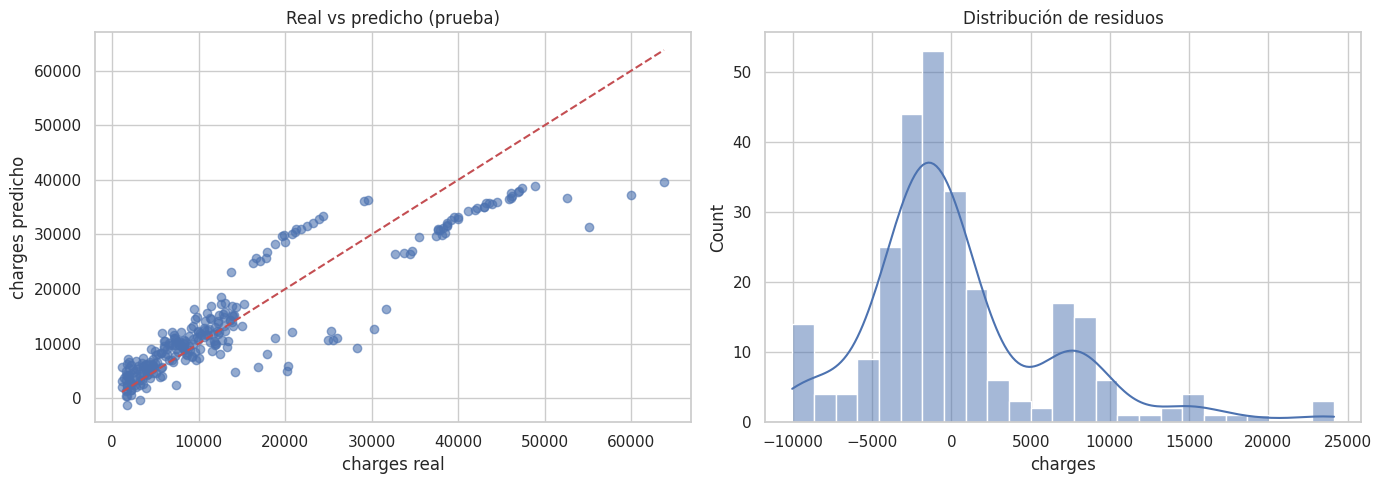

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, pred_test, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("charges real")
axes[0].set_ylabel("charges predicho")
axes[0].set_title("Real vs predicho (prueba)")

residuos = y_test - pred_test
sns.histplot(residuos, kde=True, ax=axes[1])
axes[1].set_title("Distribución de residuos")

plt.tight_layout()
plt.show()

### Interpretación
Si el R² de entrenamiento y el de prueba son parecidos, el modelo no está sobreajustado. El MAE indica cuántos dólares se equivoca el modelo en promedio. Los residuos suelen mostrar errores mayores en los gastos altos, porque la relación entre `charges` y las variables no es del todo lineal.

## 10. Predicción con nuevos datos
Creo tres pacientes ficticios y les aplico las mismas transformaciones que a los datos originales antes de predecir.

In [22]:
nuevos = pd.DataFrame({
    "age":      [25, 45, 60],
    "sex":      ["male", "female", "male"],
    "bmi":      [22.5, 31.0, 35.2],
    "children": [0, 2, 3],
    "smoker":   ["no", "yes", "no"],
    "region":   ["southwest", "southeast", "northeast"],
})

def preparar(d):
    d = d.copy()
    d["sex"] = d["sex"].map({"female": 0, "male": 1})
    d["smoker"] = d["smoker"].map({"no": 0, "yes": 1})
    for r in ["northwest", "southeast", "southwest"]:
        d[f"region_{r}"] = (d["region"] == r).astype(int)
    return d.drop(columns="region")[X.columns]

pred_nuevos = modelo.predict(preparar(nuevos))
resultado = nuevos.copy()
resultado["charges_estimado"] = pred_nuevos.round(2)
display(resultado)

,age,sex,bmi,children,smoker,region,charges_estimado
0,25,male,22.5,0,no,southwest,1564.13
1,45,female,31.0,2,yes,southeast,33222.56
2,60,male,35.2,3,no,northeast,16363.14


### Resultado
El modelo estima gastos médicos para cada paciente nuevo. Como se esperaba por el EDA, el paciente fumador tiene la estimación más alta.